Sameed Ul Hassan

## AI/ML Internship Week 1 Practical Task: Students Performance in Exams Dataset Analysis

### Part A: Setup & Inspection

#### Step 1: Import Libraries and Display Versions

In [3]:
# Step 1: Import numpy, pandas, matplotlib.pyplot, and seaborn.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Filter warnings
warnings.filterwarnings('ignore')

# Create a DataFrame to display library versions
data = {
    'Library': ['NumPy', 'Pandas', 'Matplotlib', 'Seaborn'],
    'Version': [np.__version__, pd.__version__, plt.matplotlib.__version__, sns.__version__] # Corrected Matplotlib version access
}
versions_df = pd.DataFrame(data)

print("Library Versions:")
display(versions_df)


Library Versions:


,Library,Version
0,NumPy,2.0.2
1,Pandas,2.2.2
2,Matplotlib,3.10.0
3,Seaborn,0.13.2


#### Step 2: Load the Dataset and Display Samples

Assuming the dataset is named `StudentsPerformance.csv` and is available in the Colab environment. If not, please upload it or update the file path.

In [6]:
from google.colab import files
uploaded = files.upload()

# After selecting the file, you can load it
import pandas as pd
df = pd.read_csv('StudentsPerformance.csv')

print("First 10 rows:")
display(df.head(10))

print("\nLast 5 rows:")
display(df.tail(5))

print("\nRandom sample of 8 rows:")
display(df.sample(8))


Saving StudentsPerformance.csv to StudentsPerformance.csv
First 10 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50



Last 5 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86



Random sample of 8 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
609,female,group B,associate's degree,standard,none,58,63,65
317,male,group C,associate's degree,standard,none,83,72,78
937,female,group E,high school,free/reduced,none,57,58,57
775,female,group B,some high school,free/reduced,none,49,58,55
893,male,group D,some high school,standard,completed,88,74,75
399,male,group D,some high school,standard,none,60,59,54
613,female,group C,associate's degree,standard,none,65,77,74
371,female,group C,some college,free/reduced,completed,45,73,70


#### Step 3: Perform Structure Analysis

In [7]:
# Step 3: Perform a structure analysis
print("Dataset Shape:", df.shape)

print("\nDataset Info:")
df.info()

print("\nDataset Data Types:")
display(df.dtypes)

# Count categorical vs numerical columns
num_cols = df.select_dtypes(include=np.number).shape[1]
cat_cols = df.select_dtypes(include='object').shape[1]

print(f"\nNumber of Numerical Columns: {num_cols}")
print(f"Number of Categorical Columns: {cat_cols}")


Dataset Shape: (1000, 8)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

Dataset Data Types:


,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64



Number of Numerical Columns: 3
Number of Categorical Columns: 5


#### Step 4: Check for Missing Values and Duplicates

In [8]:
# Step 4: Check for missing values
missing_values = df.isnull().sum()
print("Missing Values per Column:\n", missing_values[missing_values > 0])

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of Duplicate Rows: {duplicates}")

# Create a bar chart showing missing values per column
if missing_values.sum() > 0:
    plt.figure(figsize=(10, 6))
    missing_values[missing_values > 0].plot(kind='bar', color='skyblue')
    plt.title('Missing Values Per Column')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")

if duplicates > 0:
    print("Handling duplicates by dropping them (if any).")
    df.drop_duplicates(inplace=True)
    print(f"Number of Duplicate Rows after dropping: {df.duplicated().sum()}")


Missing Values per Column:
 Series([], dtype: int64)

Number of Duplicate Rows: 0
No missing values found in the dataset.


#### Step 5: Generate Descriptive Statistics for Scores

In [10]:
# Step 5: Generate descriptive statistics for math, reading, and writing scores
score_cols = ['math score', 'reading score', 'writing score']

# Calculate mean, median, mode, and range for each score column
def calculate_mode(series):
    return series.mode()[0] if not series.mode().empty else np.nan

def calculate_range(series):
    return series.max() - series.min()

# Collect statistics for each score column
stats_list = []
for col in score_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = calculate_mode(df[col])
    range_val = calculate_range(df[col])
    stats_list.append({
        'mean': mean_val,
        'median': median_val,
        'mode': mode_val,
        'range': range_val
    })

score_stats = pd.DataFrame(stats_list, index=score_cols)

print("Descriptive Statistics for Scores:")
display(score_stats)

# Also display general descriptive statistics for numerical columns
print("\nGeneral Descriptive Statistics for Numerical Columns:")
display(df[score_cols].describe())


Descriptive Statistics for Scores:


,mean,median,mode,range
math score,66.089,66.0,65,100
reading score,69.169,70.0,72,83
writing score,68.054,69.0,74,90



General Descriptive Statistics for Numerical Columns:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Part B: Statistical Analysis

#### Step 6: Analyze Categorical Distributions

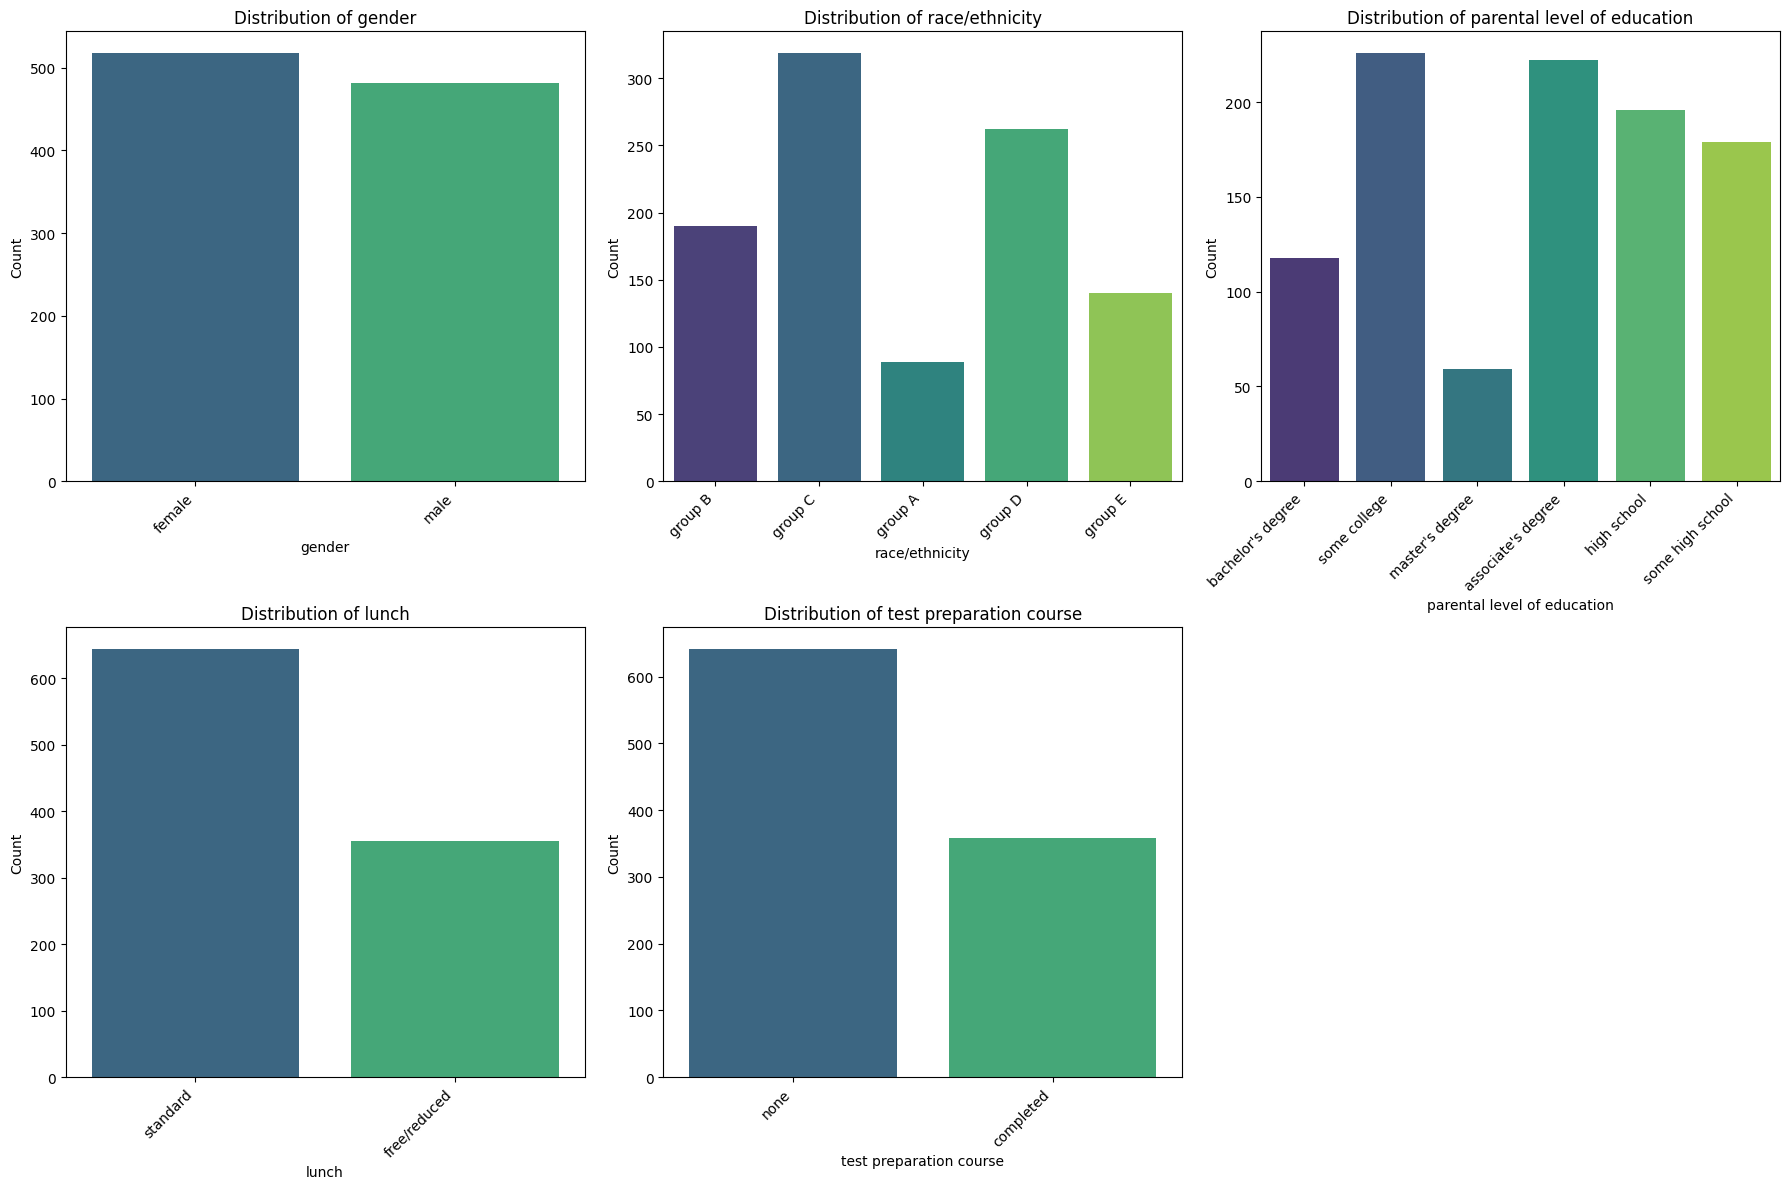

In [11]:
# Step 6: Analyze categorical distributions
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### Step 7: Group Data to Compare Mean Scores Across Categories

Mean Scores by Gender:


,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203



Mean Scores by Race/Ethnicity:


,math score,reading score,writing score
race/ethnicity,,,
group A,61.629213,64.674157,62.674157
group B,63.452632,67.352632,65.600000
group C,64.463950,69.103448,67.827586
group D,67.362595,70.030534,70.145038
group E,73.821429,73.028571,71.407143



Mean Scores by Parental Level of Education:


...


Mean Scores by Lunch Type:


,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256



Mean Scores by Test Preparation Course:


,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


<Figure size 1200x700 with 0 Axes>

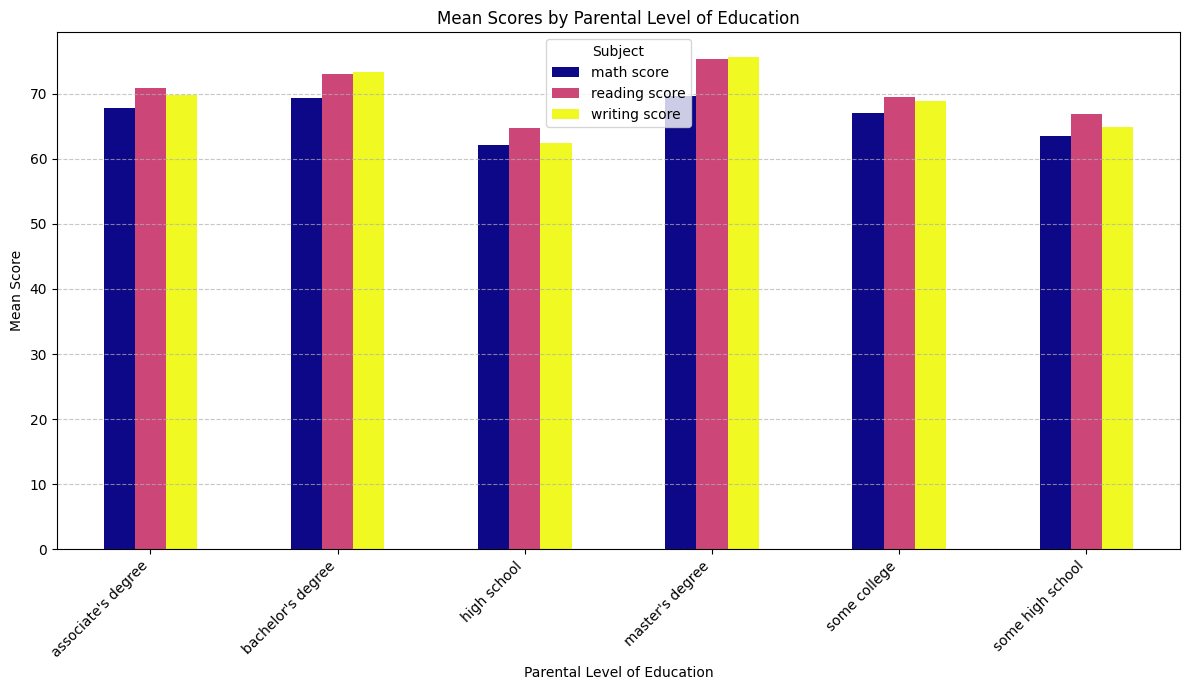

In [12]:
# Step 7: Group the data to compare mean scores across all categories
score_cols = ['math score', 'reading score', 'writing score']

print("Mean Scores by Gender:")
display(df.groupby('gender')[score_cols].mean())

print("\nMean Scores by Race/Ethnicity:")
display(df.groupby('race/ethnicity')[score_cols].mean())

print("\nMean Scores by Parental Level of Education:")
display(df.groupby('parental level of education')[score_cols].mean())

print("\nMean Scores by Lunch Type:")
display(df.groupby('lunch')[score_cols].mean())

print("\nMean Scores by Test Preparation Course:")
display(df.groupby('test preparation course')[score_cols].mean())

# Create a grouped bar chart for parental education vs scores
plt.figure(figsize=(12, 7))
parental_edu_scores = df.groupby('parental level of education')[score_cols].mean()
parental_edu_scores.plot(kind='bar', figsize=(12, 7), colormap='plasma')
plt.title('Mean Scores by Parental Level of Education')
plt.xlabel('Parental Level of Education')
plt.ylabel('Mean Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subject')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### Step 8: Compute Correlation Matrix and Display as Heatmap

Correlation Matrix of Scores:


,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


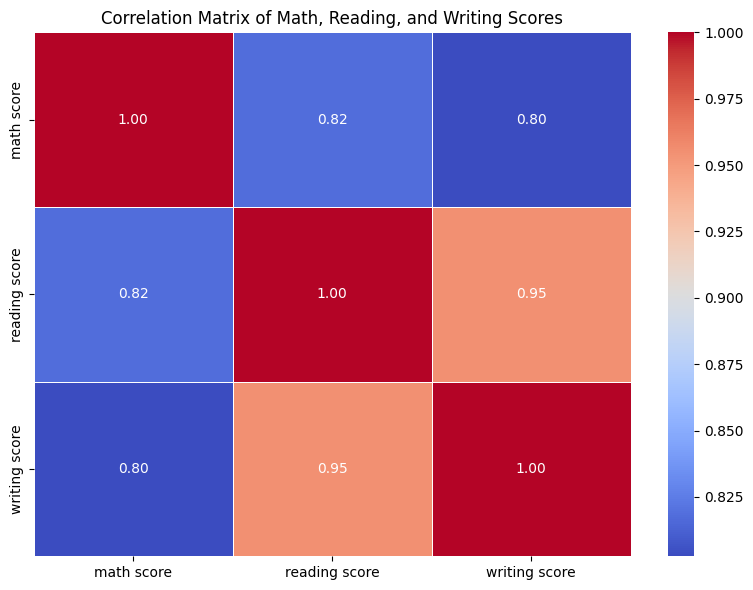

In [13]:
# Step 8: Compute a correlation matrix for the scores
correlation_matrix = df[score_cols].corr()

print("Correlation Matrix of Scores:")
display(correlation_matrix)

# Display it as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Math, Reading, and Writing Scores')
plt.tight_layout()
plt.show()


#### Step 9: Box Plots for Impact of Test Preparation Course

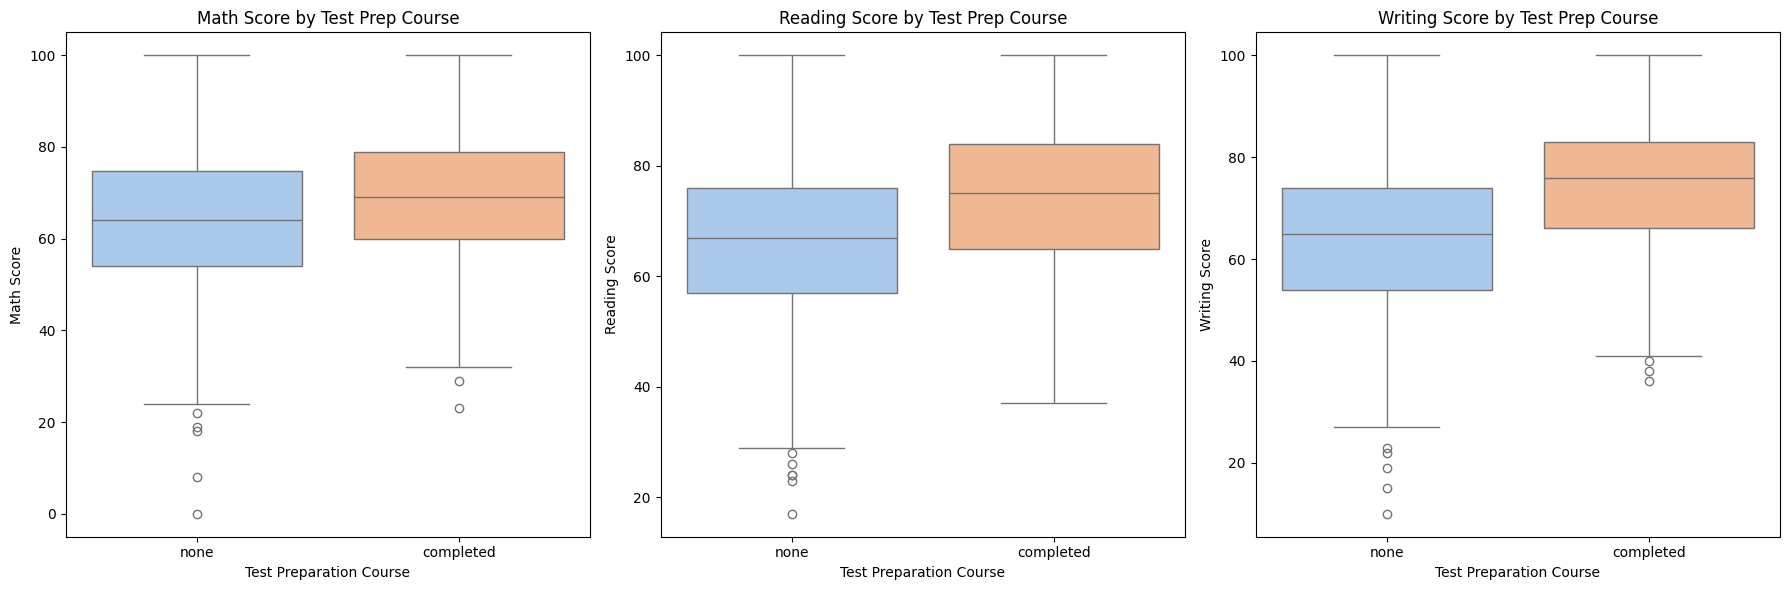

In [14]:
# Step 9: Use box plots to compare the impact of the test preparation course on all three subjects
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.boxplot(x='test preparation course', y='math score', data=df, palette='pastel')
plt.title('Math Score by Test Prep Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Math Score')

plt.subplot(1, 3, 2)
sns.boxplot(x='test preparation course', y='reading score', data=df, palette='pastel')
plt.title('Reading Score by Test Prep Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Reading Score')

plt.subplot(1, 3, 3)
sns.boxplot(x='test preparation course', y='writing score', data=df, palette='pastel')
plt.title('Writing Score by Test Prep Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Writing Score')

plt.tight_layout()
plt.show()


#### Step 10: Overlapping Histograms for Scores by Gender

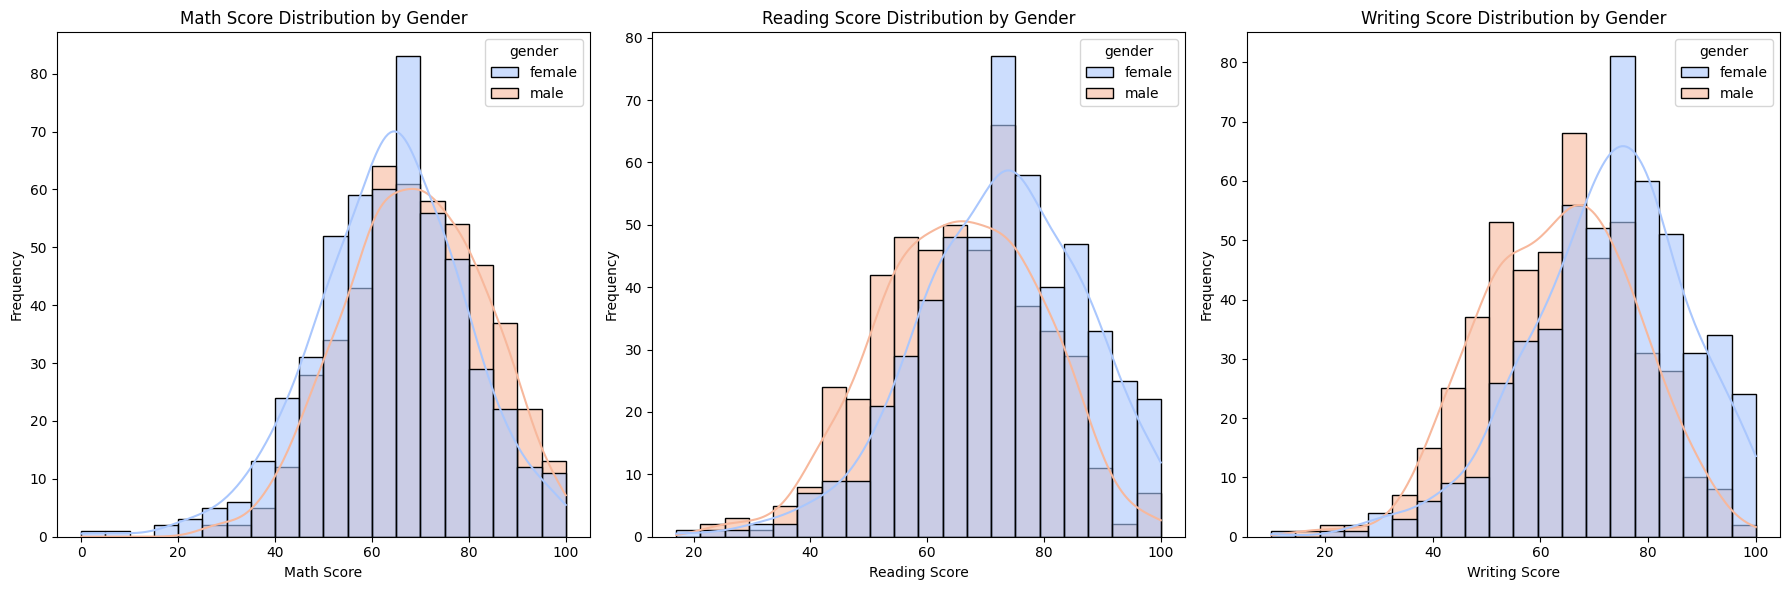

In [15]:
# Step 10: Create overlapping histograms for math, reading, and writing scores by gender
plt.figure(figsize=(18, 6))

# Math Score by Gender
plt.subplot(1, 3, 1)
sns.histplot(data=df, x='math score', hue='gender', kde=True, palette='coolwarm', alpha=0.6, bins=20)
plt.title('Math Score Distribution by Gender')
plt.xlabel('Math Score')
plt.ylabel('Frequency')

# Reading Score by Gender
plt.subplot(1, 3, 2)
sns.histplot(data=df, x='reading score', hue='gender', kde=True, palette='coolwarm', alpha=0.6, bins=20)
plt.title('Reading Score Distribution by Gender')
plt.xlabel('Reading Score')
plt.ylabel('Frequency')

# Writing Score by Gender
plt.subplot(1, 3, 3)
sns.histplot(data=df, x='writing score', hue='gender', kde=True, palette='coolwarm', alpha=0.6, bins=20)
plt.title('Writing Score Distribution by Gender')
plt.xlabel('Writing Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


### Part C: Feature Engineering & Functions

#### Step 11: Create Five New Columns

In [16]:
# Step 11: Create five new columns

# 1. total_score
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']

# 2. average_score
df['average_score'] = df['total_score'] / 3

# 3. performance_grade (A-F)
def assign_grade(score):
    if score >= 90: return 'A'
    elif score >= 80: return 'B'
    elif score >= 70: return 'C'
    elif score >= 60: return 'D'
    else: return 'F'
df['performance_grade'] = df['average_score'].apply(assign_grade)

# 4. high_achiever (True/False, e.g., average score >= 80)
df['high_achiever'] = df['average_score'] >= 80

# 5. lowest_subject
# Create a temporary DataFrame with only score columns to find the minimum
score_only_df = df[['math score', 'reading score', 'writing score']]
df['lowest_subject'] = score_only_df.idxmin(axis=1).apply(lambda x: x.replace(' score', ''))

print("DataFrame with new features:")
display(df.head())


DataFrame with new features:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score,performance_grade,high_achiever,lowest_subject
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,C,False,math
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,B,True,math
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,A,True,math
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,F,False,writing
4,male,group C,some college,standard,none,76,78,75,229,76.333333,C,False,writing


#### Step 12: Generate Two Pair Plots

Pair Plot colored by Gender:


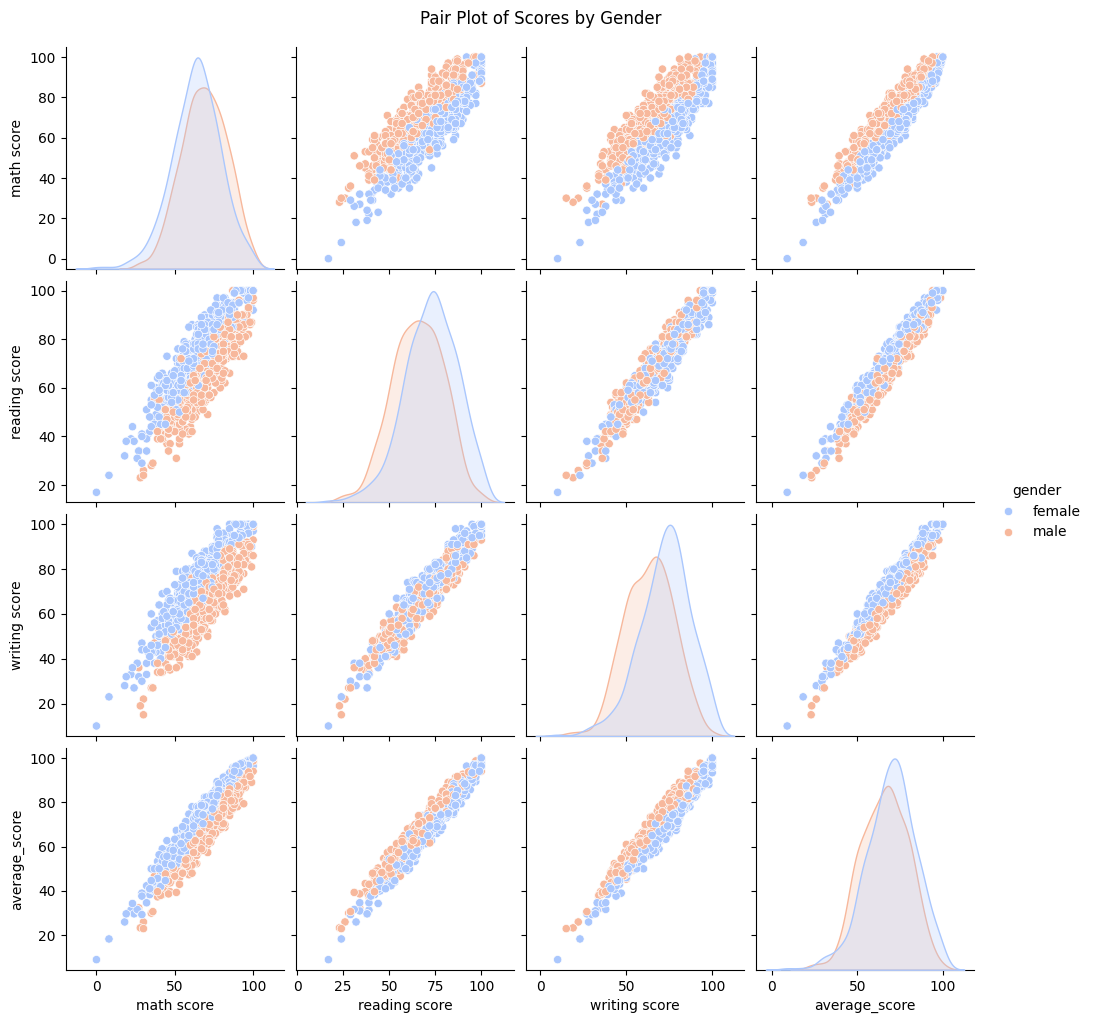


Pair Plot colored by Performance Grade:


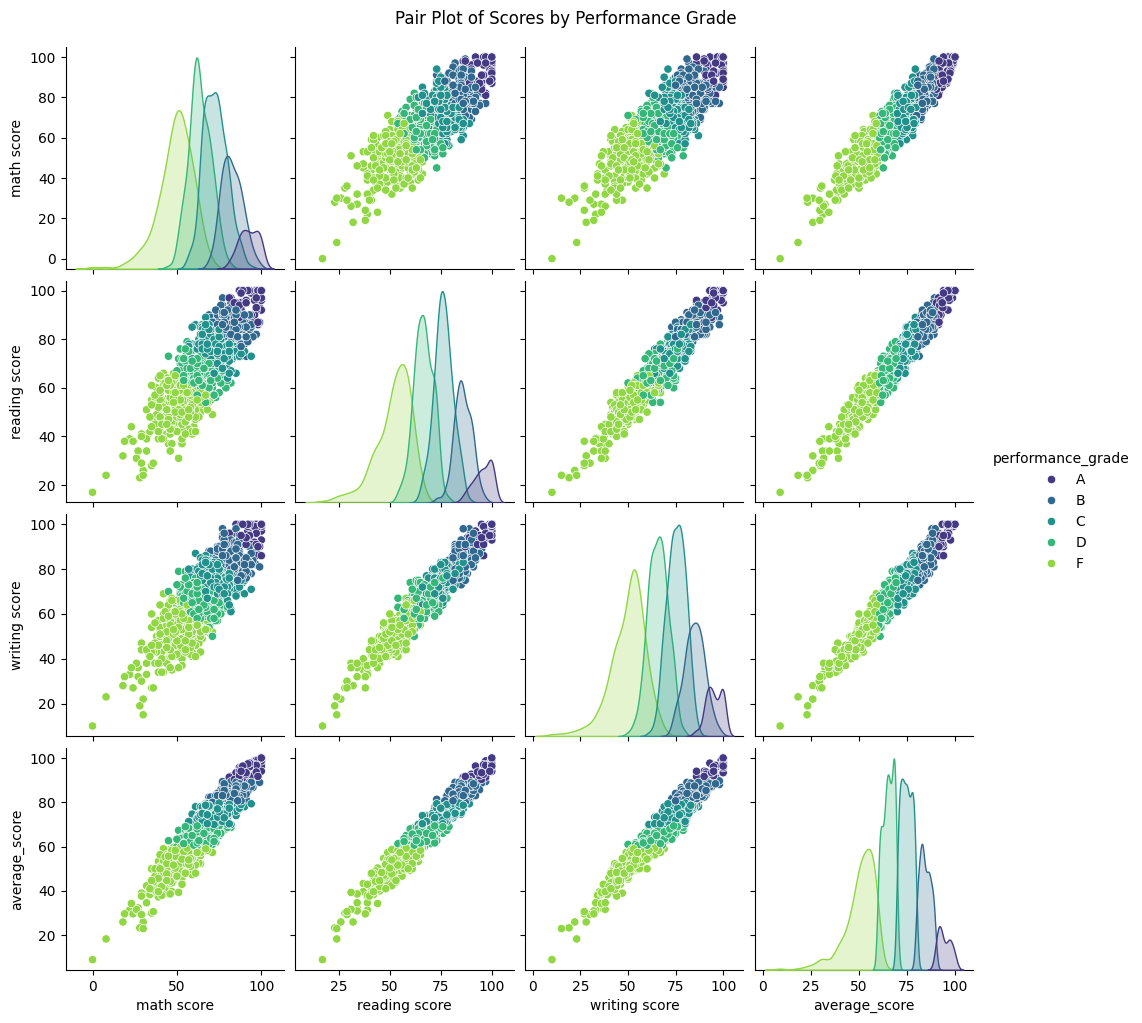

In [17]:
# Step 12: Generate two pair plots (using sns.pairplot)

# Pair plot colored by gender
print("Pair Plot colored by Gender:")
sns.pairplot(df, hue='gender', vars=['math score', 'reading score', 'writing score', 'average_score'], palette='coolwarm')
plt.suptitle('Pair Plot of Scores by Gender', y=1.02) # Adjust title position
plt.show()

# Pair plot colored by performance grade
print("\nPair Plot colored by Performance Grade:")
# Ensure grades are ordered correctly for better visualization
grade_order = ['A', 'B', 'C', 'D', 'F']
df['performance_grade'] = pd.Categorical(df['performance_grade'], categories=grade_order, ordered=True)
sns.pairplot(df, hue='performance_grade', vars=['math score', 'reading score', 'writing score', 'average_score'], palette='viridis')
plt.suptitle('Pair Plot of Scores by Performance Grade', y=1.02)
plt.show()


#### Step 13: Create Pivot Tables and Heatmaps

Pivot Table: Parental Education vs Gender (Mean Average Score):


gender,female,male
parental level of education,,
associate's degree,71.123563,67.867925
bachelor's degree,74.671958,68.775758
high school,64.748227,61.575163
master's degree,73.648148,73.521739
some college,71.002825,65.716049
some high school,65.564103,64.636364


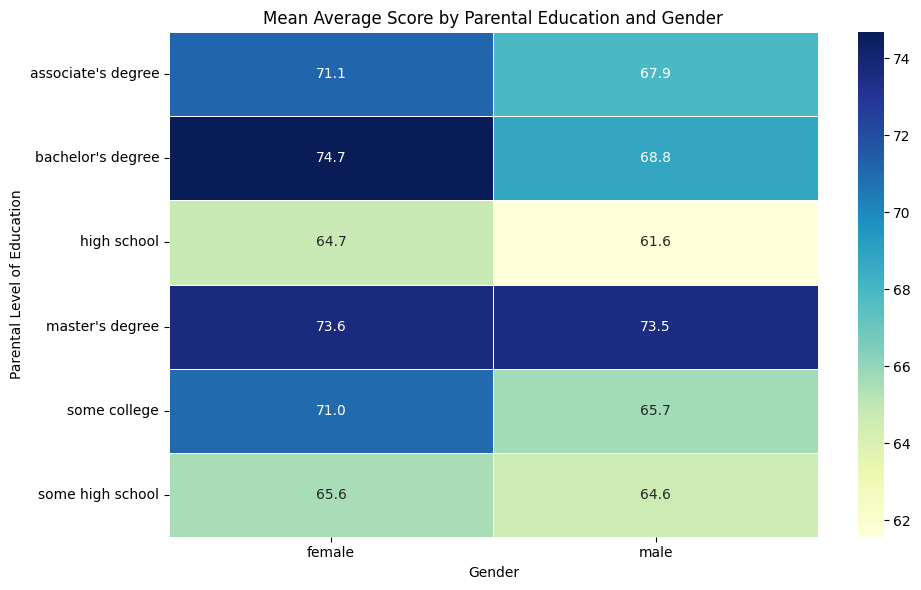


Pivot Table: Race/Ethnicity vs Test Preparation Course (Mean Average Score):


test preparation course,completed,none
race/ethnicity,,
group A,70.064516,59.212644
group B,70.642157,62.584699
group C,71.868946,64.387789
group D,73.532520,67.196296
group E,76.694444,69.795833


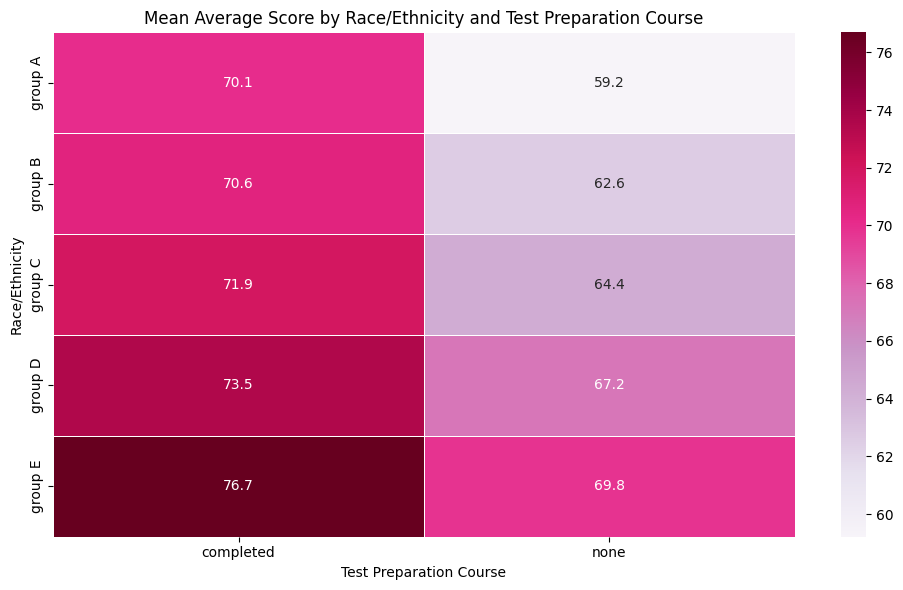

In [18]:
# Step 13: Create pivot tables and heatmaps

# Pivot table: parental education vs gender (mean average score)
parental_gender_pivot = pd.pivot_table(df, index='parental level of education', columns='gender', values='average_score', aggfunc='mean')
print("Pivot Table: Parental Education vs Gender (Mean Average Score):")
display(parental_gender_pivot)

plt.figure(figsize=(10, 6))
sns.heatmap(parental_gender_pivot, annot=True, cmap='YlGnBu', fmt=".1f", linewidths=.5)
plt.title('Mean Average Score by Parental Education and Gender')
plt.xlabel('Gender')
plt.ylabel('Parental Level of Education')
plt.tight_layout()
plt.show()

# Pivot table: race/ethnicity vs test prep (mean average score)
race_testprep_pivot = pd.pivot_table(df, index='race/ethnicity', columns='test preparation course', values='average_score', aggfunc='mean')
print("\nPivot Table: Race/Ethnicity vs Test Preparation Course (Mean Average Score):")
display(race_testprep_pivot)

plt.figure(figsize=(10, 6))
sns.heatmap(race_testprep_pivot, annot=True, cmap='PuRd', fmt=".1f", linewidths=.5)
plt.title('Mean Average Score by Race/Ethnicity and Test Preparation Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Race/Ethnicity')
plt.tight_layout()
plt.show()


#### Step 14: Write Reusable Functions


--- Demonstrating Reusable Functions ---

Summary Statistics for math score:


,math score
Mean,66.089
Median,66.000
Mode,65.000
Range,100.000


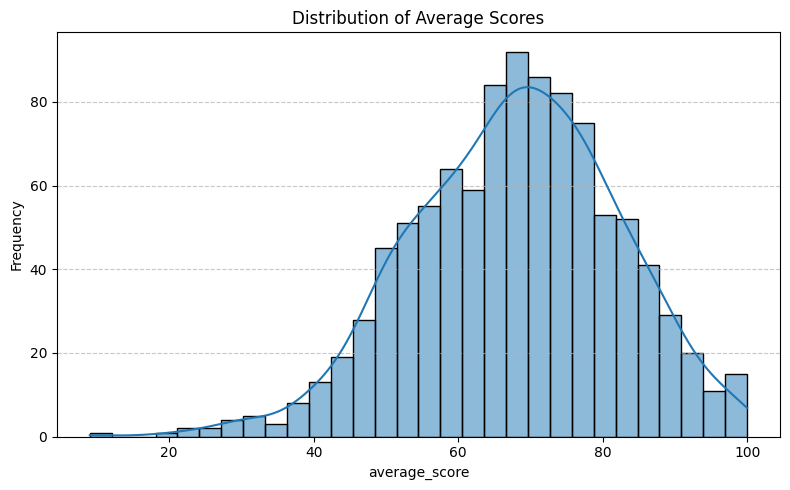


Mean Scores by parental level of education:


,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


<Figure size 1200x700 with 0 Axes>

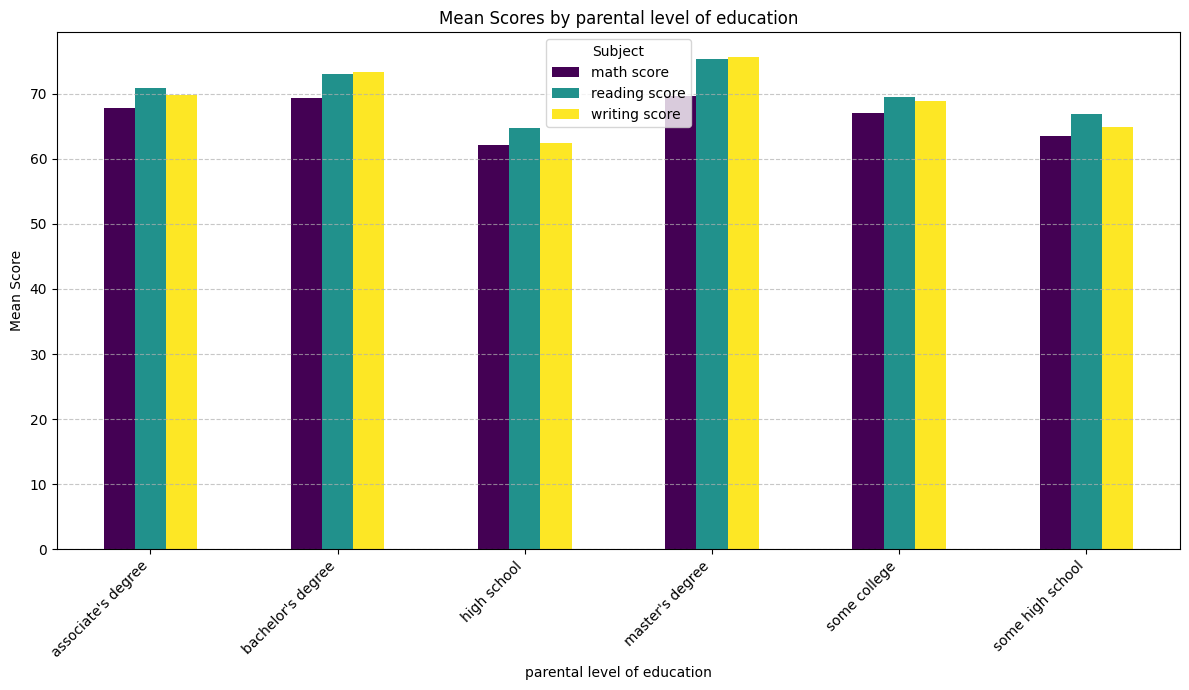

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


In [19]:
# Step 14: Write three reusable functions

def score_summary(dataframe, score_col):
    """
    Calculates and prints summary statistics (mean, median, mode, range) for a given score column.

    Parameters:
    dataframe (pd.DataFrame): The input DataFrame.
    score_col (str): The name of the score column.

    Returns:
    pd.Series: A Series containing the calculated statistics.
    """
    if score_col not in dataframe.columns:
        print(f"Error: Column '{score_col}' not found in DataFrame.")
        return None

    mean_val = dataframe[score_col].mean()
    median_val = dataframe[score_col].median()
    mode_val = dataframe[score_col].mode()[0] if not dataframe[score_col].mode().empty else np.nan
    range_val = dataframe[score_col].max() - dataframe[score_col].min()

    summary = pd.Series({
        'Mean': mean_val,
        'Median': median_val,
        'Mode': mode_val,
        'Range': range_val
    }, name=score_col)

    print(f"\nSummary Statistics for {score_col}:")
    display(summary)
    return summary


def plot_distribution(dataframe, col, title, bins=30, kde=True):
    """
    Plots the distribution of a numerical column using a histogram with KDE.

    Parameters:
    dataframe (pd.DataFrame): The input DataFrame.
    col (str): The name of the column to plot.
    title (str): The title of the plot.
    bins (int): Number of bins for the histogram (default is 30).
    kde (bool): Whether to plot a kernel density estimate (default is True).
    """
    if col not in dataframe.columns:
        print(f"Error: Column '{col}' not found in DataFrame.")
        return
    if not pd.api.types.is_numeric_dtype(dataframe[col]):
        print(f"Error: Column '{col}' is not numeric and cannot be plotted as a distribution.")
        return

    plt.figure(figsize=(8, 5))
    sns.histplot(data=dataframe, x=col, bins=bins, kde=kde, palette='GnBu')
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def compare_groups(dataframe, group_col, score_cols, plot_type='bar'):
    """
    Compares mean scores across different groups of a categorical column.
    Optionally plots a bar chart of the comparison.

    Parameters:
    dataframe (pd.DataFrame): The input DataFrame.
    group_col (str): The categorical column to group by.
    score_cols (list): A list of numerical score columns to compare.
    plot_type (str): Type of plot to generate ('bar' or None for no plot). Default is 'bar'.

    Returns:
    pd.DataFrame: A DataFrame with mean scores for each group.
    """
    if group_col not in dataframe.columns:
        print(f"Error: Group column '{group_col}' not found in DataFrame.")
        return None
    for col in score_cols:
        if col not in dataframe.columns:
            print(f"Error: Score column '{col}' not found in DataFrame.")
            return None

    grouped_means = dataframe.groupby(group_col)[score_cols].mean()
    print(f"\nMean Scores by {group_col}:")
    display(grouped_means)

    if plot_type == 'bar':
        plt.figure(figsize=(12, 7))
        grouped_means.plot(kind='bar', figsize=(12, 7), colormap='viridis')
        plt.title(f'Mean Scores by {group_col}')
        plt.xlabel(group_col)
        plt.ylabel('Mean Score')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Subject')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    return grouped_means

# Demonstrating the functions
print("\n--- Demonstrating Reusable Functions ---")
score_summary(df, 'math score')
plot_distribution(df, 'average_score', 'Distribution of Average Scores')
compare_groups(df, 'parental level of education', ['math score', 'reading score', 'writing score'])


#### Step 15: Use Only NumPy for Z-scores, Percentiles, and Pass Rates

In [20]:
# Step 15: Use only NumPy to compute Z-scores, percentiles, and pass rates
score_cols_np = ['math score', 'reading score', 'writing score']

for col in score_cols_np:
    scores = df[col].values # Convert pandas Series to NumPy array

    # Compute Z-scores
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    z_scores = (scores - mean_score) / std_score
    print(f"\nZ-scores for {col} (first 5): {z_scores[:5]}")

    # Compute Percentiles (10, 25, 50, 75, 90)
    percentiles = np.percentile(scores, [10, 25, 50, 75, 90])
    print(f"Percentiles for {col} (10th, 25th, 50th, 75th, 90th): {percentiles}")

    # Compute Pass Rates (assuming a passing score of 60)
    passing_score = 60
    pass_rate = np.mean(scores >= passing_score) * 100
    print(f"Pass Rate for {col} (>= {passing_score}): {pass_rate:.2f}%")



Z-scores for math score (first 5): [ 0.39002351  0.19207553  1.57771141 -1.25954302  0.65395415]
Percentiles for math score (10th, 25th, 50th, 75th, 90th): [47. 57. 66. 77. 86.]
Pass Rate for math score (>= 60): 67.70%

Z-scores for reading score (first 5): [ 0.19399858  1.42747598  1.77010859 -0.83389925  0.60515772]
Percentiles for reading score (10th, 25th, 50th, 75th, 90th): [51.  59.  70.  79.  87.1]
Pass Rate for reading score (>= 60): 74.60%

Z-scores for writing score (first 5): [ 0.39149181  1.31326868  1.64247471 -1.58374436  0.45733301]
Percentiles for writing score (10th, 25th, 50th, 75th, 90th): [48.   57.75 69.   79.   87.  ]
Pass Rate for writing score (>= 60): 71.90%


### Part D: Dashboard

#### Step 16: Create a 3x2 Professional Dashboard

Dashboard 'eda_dashboard.png' saved successfully.


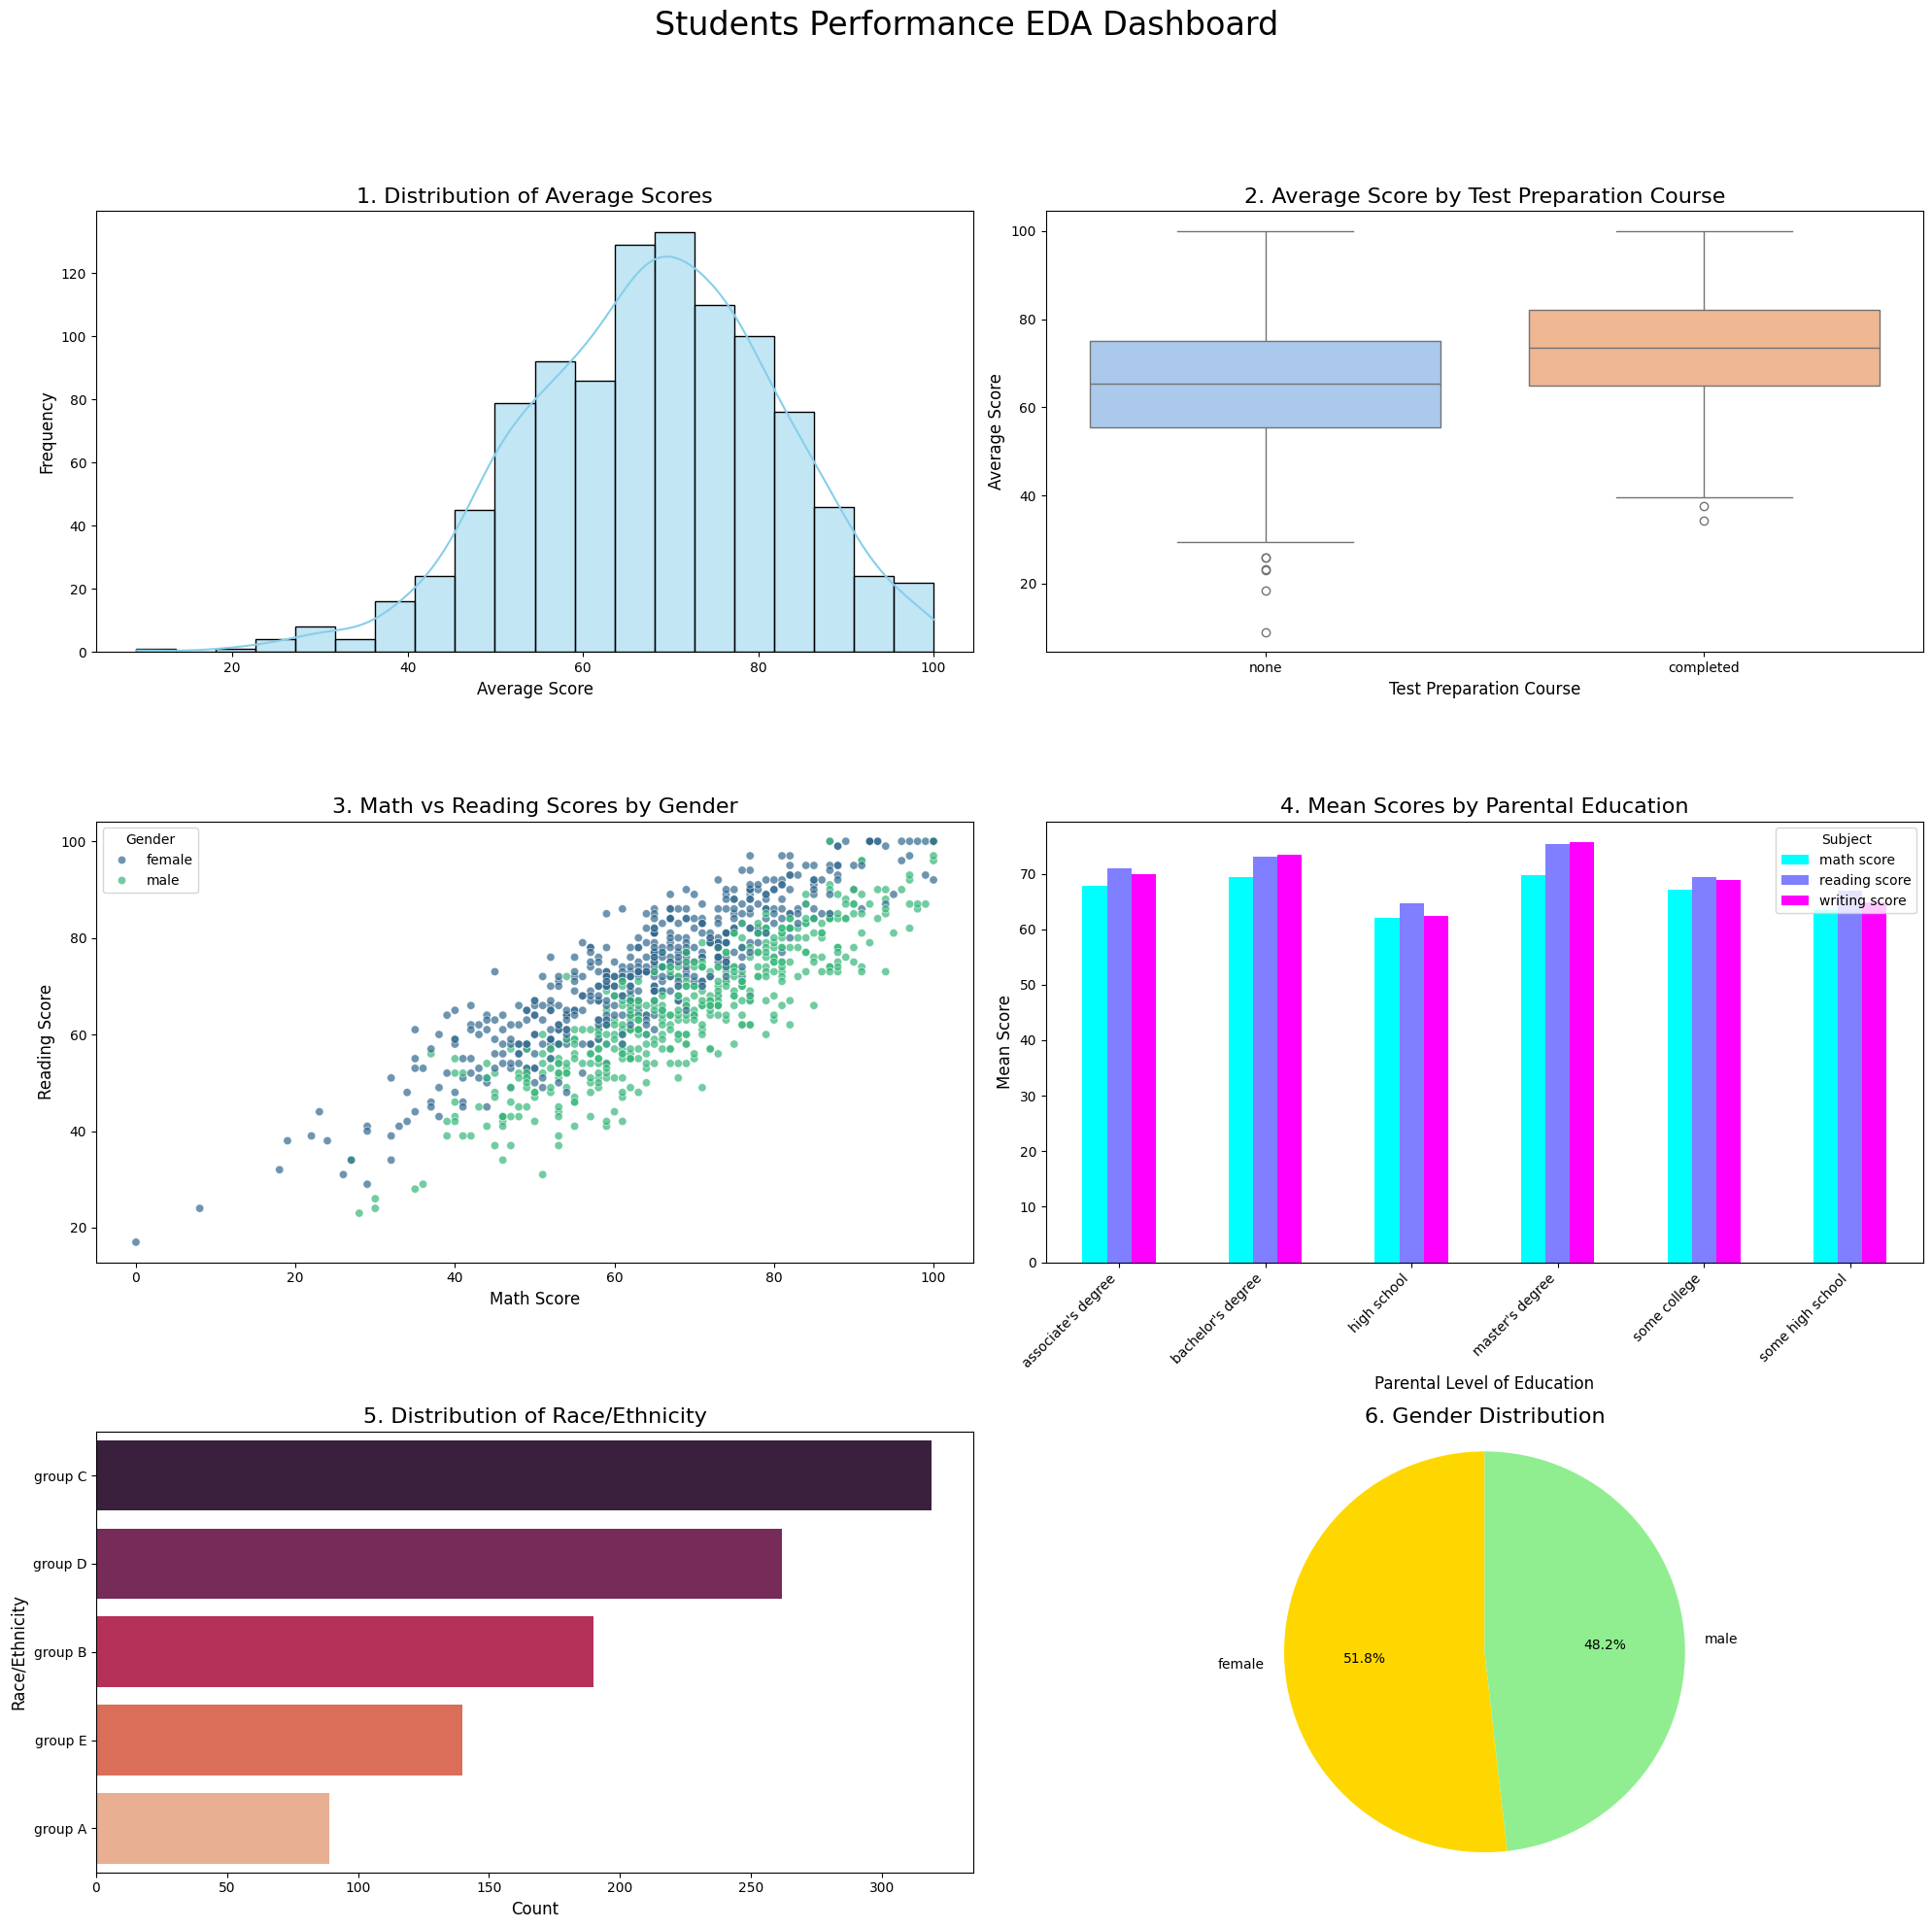

In [22]:
# Step 16: Create a 3x2 professional dashboard with 6 specific charts

plt.figure(figsize=(20, 20))
plt.suptitle('Students Performance EDA Dashboard', fontsize=24, y=1.02)

# Chart 1: Histogram of Average Score
plt.subplot(3, 2, 1)
sns.histplot(df['average_score'], bins=20, kde=True, color='skyblue')
plt.title('1. Distribution of Average Scores', fontsize=16)
plt.xlabel('Average Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Chart 2: Box Plot of Average Score by Test Preparation Course
plt.subplot(3, 2, 2)
sns.boxplot(x='test preparation course', y='average_score', data=df, palette='pastel') # Changed palette from 'lightcoral' to 'pastel'
plt.title('2. Average Score by Test Preparation Course', fontsize=16)
plt.xlabel('Test Preparation Course', fontsize=12)
plt.ylabel('Average Score', fontsize=12)

# Chart 3: Scatter Plot of Math vs Reading Scores, colored by Gender
plt.subplot(3, 2, 3)
sns.scatterplot(x='math score', y='reading score', hue='gender', data=df, palette='viridis', alpha=0.7)
plt.title('3. Math vs Reading Scores by Gender', fontsize=16)
plt.xlabel('Math Score', fontsize=12)
plt.ylabel('Reading Score', fontsize=12)
plt.legend(title='Gender')

# Chart 4: Grouped Bar Chart of Mean Scores by Parental Level of Education
plt.subplot(3, 2, 4)
parental_edu_avg = df.groupby('parental level of education')[['math score', 'reading score', 'writing score']].mean()
parental_edu_avg.plot(kind='bar', ax=plt.gca(), colormap='cool')
plt.title('4. Mean Scores by Parental Education', fontsize=16)
plt.xlabel('Parental Level of Education', fontsize=12)
plt.ylabel('Mean Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subject')

# Chart 5: Horizontal Bar Chart of Race/Ethnicity Distribution
plt.subplot(3, 2, 5)
sns.countplot(y='race/ethnicity', data=df, order=df['race/ethnicity'].value_counts().index, palette='rocket')
plt.title('5. Distribution of Race/Ethnicity', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Race/Ethnicity', fontsize=12)

# Chart 6: Pie Chart of Gender Distribution
plt.subplot(3, 2, 6)
gender_counts = df['gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['gold', 'lightgreen', 'lightcoral'])
plt.title('6. Gender Distribution', fontsize=16)
plt.ylabel('') # Hide y-label for pie chart clarity
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap

# Save the dashboard
plt.savefig('eda_dashboard.png')
print("Dashboard 'eda_dashboard.png' saved successfully.")
plt.show()
